<a href="https://colab.research.google.com/github/iraholdynska/Python/blob/master/python_practice_10_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Оцінювання наявності даної роботи буде враховувати як наявність самих візуалізацій (вони можуть незначно відрізнятися від прикладів, але повинні змістовно відображати суть задачі) та опис отриманих вами результатів. При наявності ЛИШЕ візуалізацій без роз'яснень, завдання не буде зараховане за наявне.

Під час виконання вам дозволено користуватися будь-якими зручними для вас Python бібліотеками для візуалізації.

# I. Receiving Data.

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

1. (2б) Для виконання цієї лабораторної роботи Вам необхідно скористатися вибіркою titanic ([train.csv](https://www.kaggle.com/c/titanic/data?select=train.csv)). Зчитайте його та збережіть його у змінну, щоб у подальшому її використати для візуалізацій. Виведіть інформацію про кожну колонку, її індекс, тип та кількість непропущених значень та перші кілька рядків датафрейму.


In [2]:
df = pd.read_csv('/content/./train.csv')

In [3]:
df.info()
df.head()
df.notna()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,True,True,True,True,True,True,True,True,True,True,False,True
1,True,True,True,True,True,True,True,True,True,True,True,True
2,True,True,True,True,True,True,True,True,True,True,False,True
3,True,True,True,True,True,True,True,True,True,True,True,True
4,True,True,True,True,True,True,True,True,True,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
886,True,True,True,True,True,True,True,True,True,True,False,True
887,True,True,True,True,True,True,True,True,True,True,True,True
888,True,True,True,True,True,False,True,True,True,True,False,True
889,True,True,True,True,True,True,True,True,True,True,True,True


# IІ. Data Visualization.

2. (10б) Створіть pie chart, який би показував співвідношення виживших до загиблих.

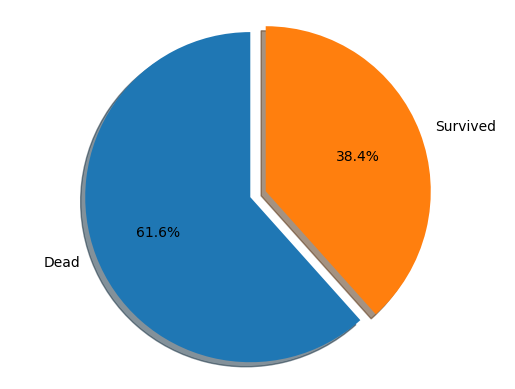

In [4]:
labels = ["Dead", "Survived"]
sizes = df["Survived"].value_counts()
explode = (0, 0.1)

fig1, ax1 = plt.subplots()
ax1.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%',
        shadow=True, startangle=90)
ax1.axis('equal')

plt.show()

відсоток мертвих набагато вищий за відсоток тих, що вижили

3. (20б) Створіть bar chart, який би показував співвідношення загиблих до виживших для кожної статі. Для groupby використовуйте атрибут as_index=False.


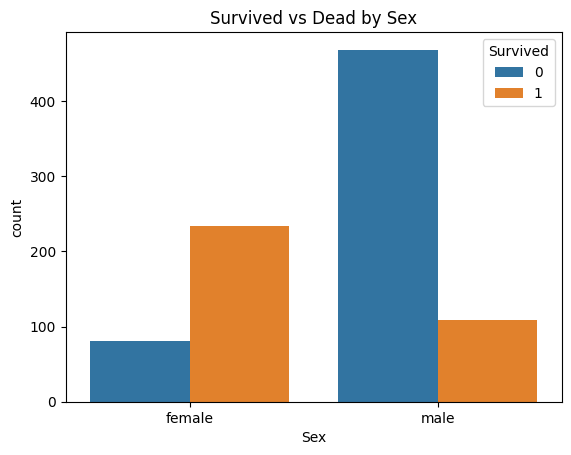

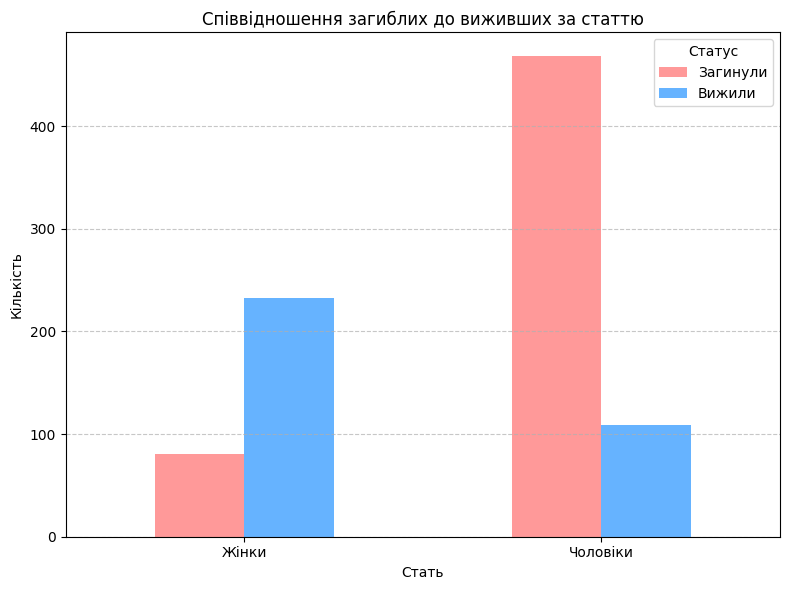

In [5]:
survival_by_gender = df.groupby(['Sex', 'Survived']).size().unstack(fill_value=0)

survival_by_gender = survival_by_gender[[0, 1]]

survival_by_gender.columns = ['Загинули', 'Вижили']
survival_by_gender.index = ['Жінки', 'Чоловіки']

survival_by_gender.plot(kind='bar', figsize=(8, 6), color=['#ff9999', '#66b3ff'])
plt.title('Співвідношення загиблих до виживших за статтю')
plt.xlabel('Стать')
plt.ylabel('Кількість')
plt.xticks(rotation=0)
plt.legend(title='Статус')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

більшість жінок вижили(підтвердження того, що жінок і дітей евакуювали перед чоловіками)

4. (20б) Відобразіть кількість пропущених значень в датасеті по кожній із змінних.

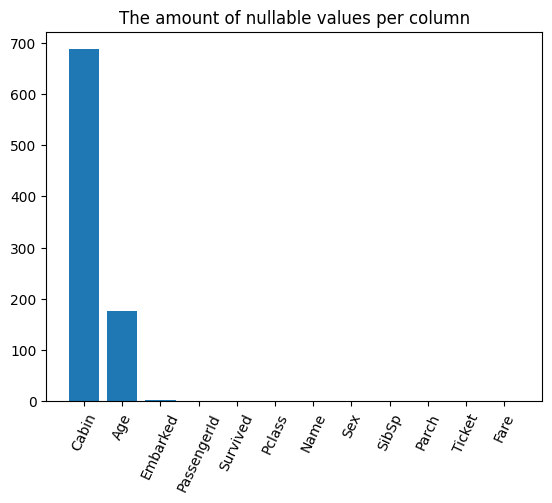

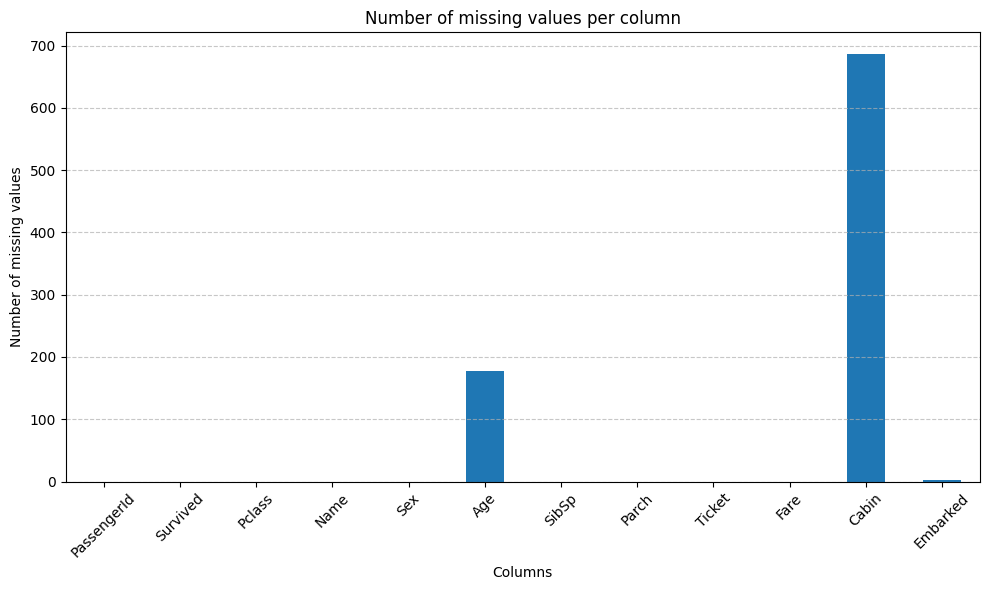

In [6]:
missing_values = df.isnull().sum()

plt.figure(figsize=(10, 6))
missing_values.plot(kind = "bar")

plt.title("Number of missing values per column")
plt.xlabel("Columns")
plt.ylabel("Number of missing values")

plt.xticks(rotation = 45)
plt.grid(axis = "y", linestyle = "--", alpha = 0.7)

plt.tight_layout()
plt.show()

Найбільше пропущених значень у змінній Cabin, також є пропущені змінні в Age. Невелика кількість у Embarked

5. (10б) Побудуйте наступний графік, дайте йому назву та опишіть, що власне на них відображається.

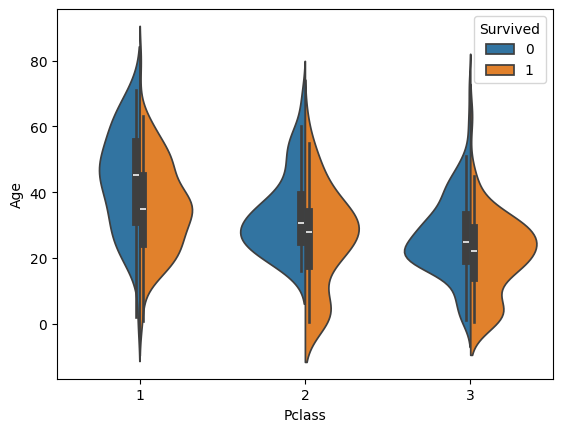

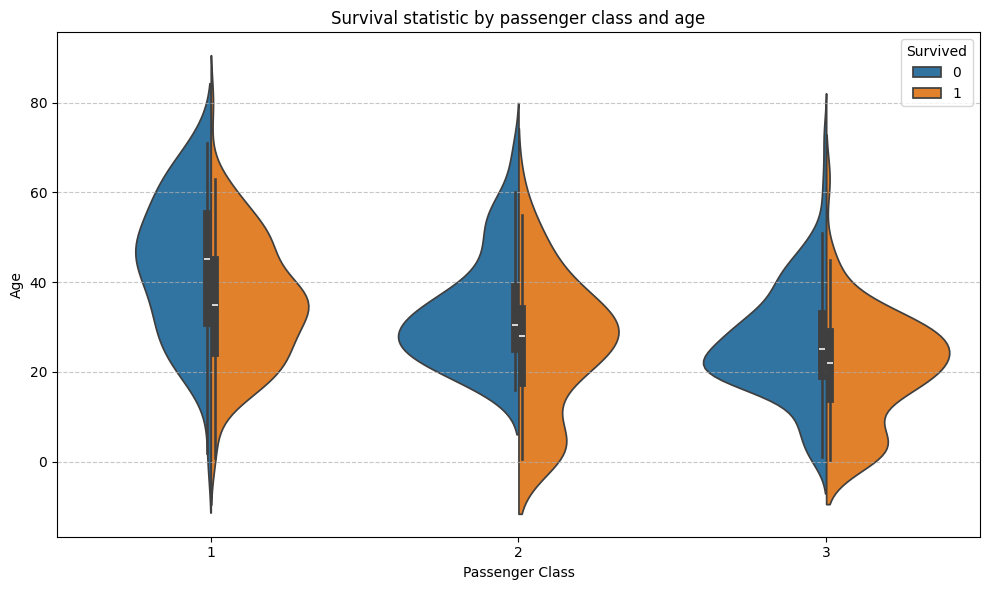

In [7]:
plt.figure(figsize = (10, 6))

sns.violinplot(x = "Pclass", y = "Age", hue = "Survived", data = df, split = True)

plt.title("Survival statistic by passenger class and age")
plt.xlabel("Passenger Class")
plt.ylabel("Age")

plt.grid(axis = "y", linestyle = "--", alpha = 0.7)

plt.tight_layout()
plt.show()

статистика виживання за віком і класом пасажирів

6. (13б) Побудуйте графік розподілу частот по віку пасажирів.


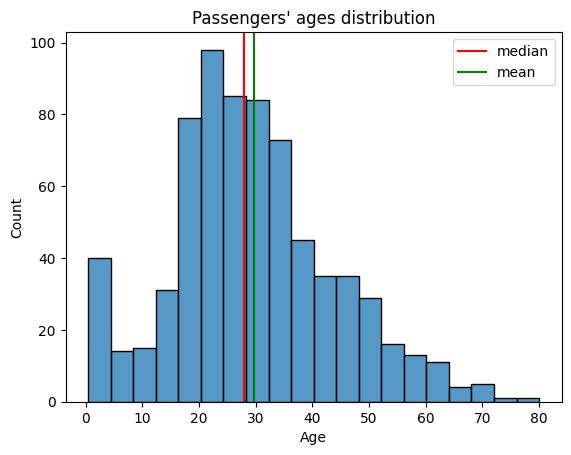

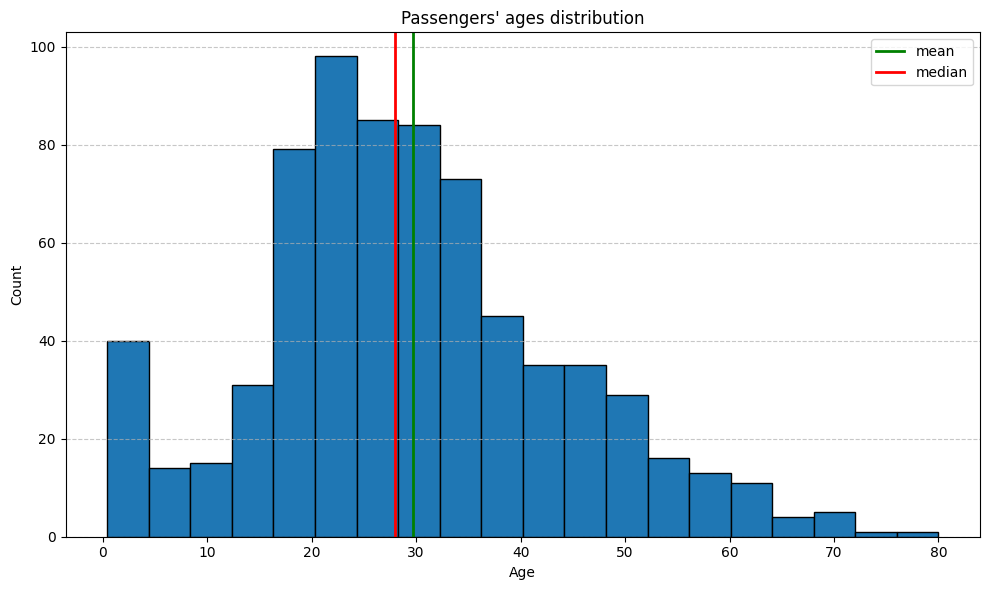

In [8]:
plt.figure(figsize = (10, 6))

age_data = df["Age"].dropna()

plt.hist(age_data, bins = 20, edgecolor = "black")

mean_age = age_data.mean()
median_age = age_data.median()

plt.axvline(mean_age, color = "green", linewidth = 2, label = "mean")
plt.axvline(median_age, color = "red", linewidth = 2, label = "median")

plt.title("Passengers' ages distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.legend()
plt.grid(axis = "y", linestyle = "--", alpha = 0.7)

plt.tight_layout()
plt.show()

статистика про кількість пасажирів по віку, зеленою лінією середній вік, червоною медіану

7. (25б) Поставте бізнес-питання до даних. Дайте на нього відповідь за допомогою візуалізацій. Прокоментуйте отриману відповідь.

Як вплинули вік і стать на виживання?

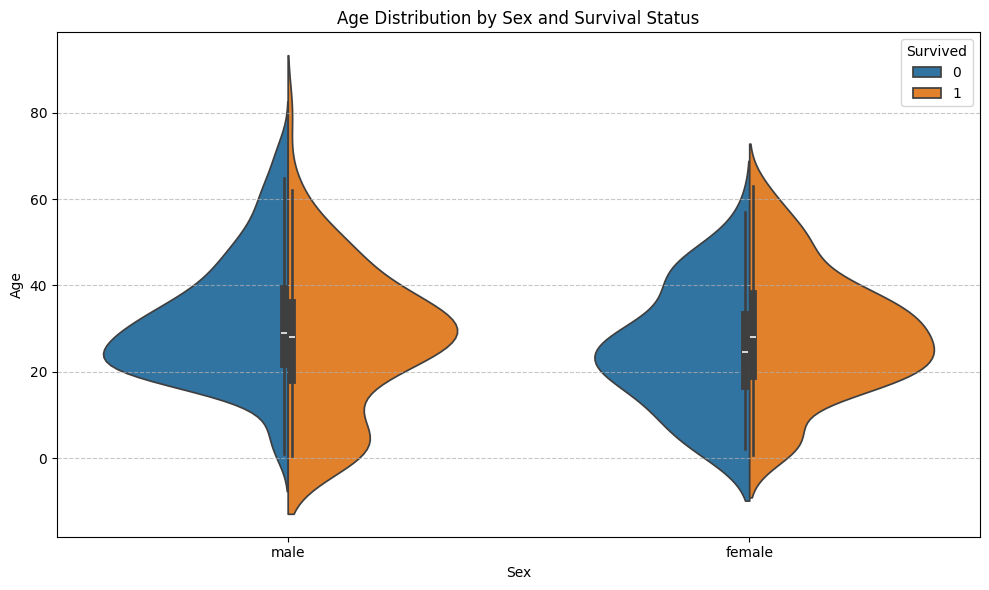

In [12]:
plt.figure(figsize=(10, 6))

sns.violinplot(x='Sex', y='Age', hue='Survived', data=df, split=True)

plt.title('Age Distribution by Sex and Survival Status')
plt.xlabel('Sex')
plt.ylabel('Age')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

сатистика виживання за віком і статтю.

видно, що сать має більший вплив на виживання.

# Вітаю! Ви велика(ий) молодець, що впоралась(вся). Похваліть себе та побалуйте чимось приємним. Я Вами пишаюся.

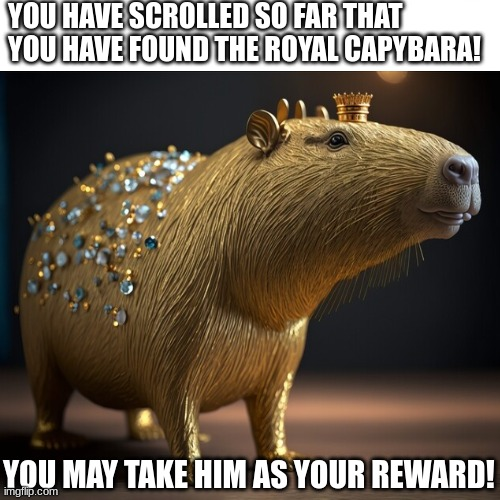